In [20]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np
from hmmlearn.hmm import GaussianHMM


In [2]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [3]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-05 00:00:00+05:30,0.000000,0.094707,0.000000,0.086095,0.000000,0.052627,0.000000,0.034146,0.049268,0.079448,...,0.022316,0.000000,0.007209,0.042414,0.000000,0.000000,0.097714,0.014177,0.101710,0.000000
2008-06-06 00:00:00+05:30,0.000000,0.096463,0.000000,0.093592,0.000000,0.055477,0.000000,0.038427,0.048164,0.072977,...,0.026902,0.000000,0.004996,0.039518,0.000000,0.000000,0.092051,0.016242,0.101359,0.000000
2008-06-09 00:00:00+05:30,0.000000,0.097814,0.000000,0.100934,0.000000,0.060673,0.000000,0.042575,0.046727,0.065568,...,0.032963,0.000000,0.002542,0.034720,0.000000,0.000000,0.085397,0.017465,0.100786,0.000000
2008-06-10 00:00:00+05:30,0.000000,0.099855,0.000000,0.104100,0.000000,0.071059,0.000000,0.047309,0.046517,0.058178,...,0.038096,0.000000,0.001713,0.030261,0.000000,0.000000,0.080686,0.019027,0.099659,0.000000
2008-06-11 00:00:00+05:30,0.000000,0.100483,0.000000,0.105155,0.000000,0.084748,0.000000,0.052642,0.045687,0.050810,...,0.045469,0.000058,0.000870,0.026759,0.000000,0.000000,0.075993,0.020184,0.097661,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12 00:00:00+05:30,0.150253,0.171876,0.110617,0.016477,0.000274,0.000000,0.104171,0.077467,0.020435,0.000000,...,0.041521,0.073654,0.000000,0.000000,0.025725,0.050502,0.000000,0.019644,0.066028,0.036041
2025-09-15 00:00:00+05:30,0.140572,0.171512,0.102708,0.012511,0.000518,0.000000,0.113352,0.073049,0.019066,0.000000,...,0.039853,0.072866,0.000000,0.000000,0.025318,0.053611,0.000000,0.021749,0.061992,0.034028
2025-09-16 00:00:00+05:30,0.128521,0.175892,0.093519,0.008835,0.000000,0.000000,0.121123,0.067323,0.016315,0.000000,...,0.037340,0.075898,0.000000,0.000000,0.024032,0.058974,0.000000,0.025540,0.057928,0.034247


In [4]:
def build_df(dataframe, start_date, days):
    df_ = dataframe.copy()

    # Ensure datetime index
    if not pd.api.types.is_datetime64_any_dtype(df_.index):
        df_.index = pd.to_datetime(df_.index)

    idx_tz = getattr(df_.index, "tz", None)

    start = pd.to_datetime(start_date)
    if idx_tz is not None:
        start = start.tz_localize(idx_tz) if start.tzinfo is None else start.tz_convert(idx_tz)

    end = start + pd.Timedelta(days=days)

    mask = (df_.index >= start) & (df_.index <= end)
    tdf = df_.loc[mask].copy()

    X = tdf.drop("Close", axis=1).to_numpy()
    return tdf, X

In [5]:
slice_df,X = build_df(df, "2023-01-01", 5000)

In [6]:
def rolling_hdbscan(
    Z,
    dates,
    window=500,
    step=10,
    min_cluster_size=30,
    min_samples=10
):
    """
    Returns:
        labels      : pd.Series (window-local cluster ids)
        centroids   : dict {t_end: {cluster_id: centroid}}
    """

    labels = pd.Series(index=dates, dtype="float")
    centroids = {}

    for end in range(window, len(Z) + 1, step):
        start = end - window
        Z_win = Z[start:end]

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom"
        )

        win_labels = clusterer.fit_predict(Z_win)

        # compute centroids (ignore noise)
        win_centroids = {}
        for c in np.unique(win_labels):
            if c == -1:
                continue
            win_centroids[c] = Z_win[win_labels == c].mean(axis=0)

        centroids[end] = win_centroids

        # assign only the last `step` points (causal)
        assign_slice = slice(end - step, end)
        labels.iloc[assign_slice] = win_labels[-step:]

    return labels, centroids


def remap_clusters(prev_centroids, new_centroids, dist_threshold=None):
    """
    Returns:
        mapping: dict {new_cluster_id -> global_cluster_id}
        unmatched_new: set of new cluster ids
    """

    if not prev_centroids:
        return {}, set(new_centroids.keys())

    prev_ids = list(prev_centroids.keys())
    new_ids = list(new_centroids.keys())

    prev_mat = np.stack([prev_centroids[i] for i in prev_ids])
    new_mat  = np.stack([new_centroids[i]  for i in new_ids])

    cost = cdist(prev_mat, new_mat)
    row_ind, col_ind = linear_sum_assignment(cost)

    mapping = {}
    unmatched_new = set(new_ids)

    for r, c in zip(row_ind, col_ind):
        if dist_threshold is None or cost[r, c] < dist_threshold:
            mapping[new_ids[c]] = prev_ids[r]
            unmatched_new.discard(new_ids[c])

    return mapping, unmatched_new

def assign_global_cluster_ids(
    local_labels: pd.Series,
    centroids: dict,
    *,
    step: int,
    dist_threshold: float | None = None,
    noise_label: int = -1,
) -> pd.Series:
    """
    Map window-local cluster IDs to stable global IDs.

    Args:
        local_labels: pd.Series indexed by dates, values are window-local cluster ids (incl. -1 for noise)
        centroids: dict {end_pos: {local_cluster_id: centroid_vec}}
        step: same step used in rolling_hdbscan (we only relabel the last `step` points per window)
        dist_threshold: optional max centroid distance for matching
        noise_label: label to keep for noise

    Returns:
        pd.Series of stable global ids (noise stays as noise_label)
    """
    global_labels = pd.Series(index=local_labels.index, dtype="Int64")
    prev_centroids: dict[int, np.ndarray] = {}
    next_global_id = 0

    # deterministic iteration
    for end in sorted(centroids.keys()):
        new_centroids = centroids[end]

        # match current window's centroids to previous global centroids
        mapping, unmatched = remap_clusters(prev_centroids, new_centroids, dist_threshold=dist_threshold)

        # assign new global IDs to unmatched clusters (stable ordering)
        for c in sorted(unmatched):
            mapping[c] = next_global_id
            next_global_id += 1

        # always keep noise as noise
        mapping[noise_label] = noise_label

        # only relabel the points that were assigned for this window (causal)
        start = max(0, end - step)
        assign_slice = slice(start, end)

        sub = local_labels.iloc[assign_slice]
        mapped = sub.map(mapping)  # unmapped -> NaN (shouldn't happen except weird edge cases)
        global_labels.iloc[assign_slice] = mapped.astype("Int64")

        # update prev centroids in global-id space (skip noise)
        prev_centroids = {
            mapping[c]: new_centroids[c]
            for c in new_centroids.keys()
            if c != noise_label and c in mapping
        }

    return global_labels

# ...existing code...

def smooth_labels(labels: pd.Series, min_duration: int = 5) -> pd.Series:
    """
    Enforces minimum regime duration, while keeping pd.NA segments intact.
    """
    if min_duration <= 1:
        return labels

    values = labels.to_numpy(dtype="object")
    smoothed = values.copy()

    start = 0
    for i in range(1, len(values)):
        prev = values[i - 1]
        curr = values[i]

        # If either side is NA, don't try to compare/smooth across it
        if pd.isna(prev) or pd.isna(curr):
            start = i
            continue

        if curr != prev:
            seg_len = i - start
            if seg_len < min_duration:
                # Prefer merging into the previous (non-NA) regime if available, else into current
                prev_regime = values[start - 1] if start > 0 else pd.NA
                fill_val = prev_regime if not pd.isna(prev_regime) else curr
                smoothed[start:i] = fill_val
            start = i

    return pd.Series(smoothed, index=labels.index, dtype="Int64")

# ...existing code...


In [7]:
# 1. Rolling HDBSCAN
local_labels, centroids = rolling_hdbscan(
    embeddings,
    dates=embeddings.index,
    window=500,
    step=10,
    min_cluster_size=30,
    min_samples=10
)

In [8]:
local_labels

Date
2008-06-05 00:00:00+05:30    NaN
2008-06-06 00:00:00+05:30    NaN
2008-06-09 00:00:00+05:30    NaN
2008-06-10 00:00:00+05:30    NaN
2008-06-11 00:00:00+05:30    NaN
                            ... 
2025-09-12 00:00:00+05:30    1.0
2025-09-15 00:00:00+05:30    1.0
2025-09-16 00:00:00+05:30   -1.0
2025-09-17 00:00:00+05:30   -1.0
2025-09-18 00:00:00+05:30   -1.0
Length: 4240, dtype: float64

In [9]:

# 2. Stable global IDs
global_labels = assign_global_cluster_ids(
    local_labels,
    centroids,
    step=10,  # must match rolling_hdbscan(..., step=10)
)


In [10]:

# 3. Smooth regime flicker
global_labels = smooth_labels(global_labels, min_duration=7)


In [11]:
global_labels.tail(20)

Date
2025-08-21 00:00:00+05:30    -1
2025-08-22 00:00:00+05:30    -1
2025-08-25 00:00:00+05:30    -1
2025-08-26 00:00:00+05:30    -1
2025-08-28 00:00:00+05:30    -1
2025-08-29 00:00:00+05:30    33
2025-09-01 00:00:00+05:30    33
2025-09-02 00:00:00+05:30    33
2025-09-03 00:00:00+05:30    33
2025-09-04 00:00:00+05:30    33
2025-09-05 00:00:00+05:30    33
2025-09-08 00:00:00+05:30    33
2025-09-09 00:00:00+05:30    33
2025-09-10 00:00:00+05:30    33
2025-09-11 00:00:00+05:30    33
2025-09-12 00:00:00+05:30    33
2025-09-15 00:00:00+05:30    33
2025-09-16 00:00:00+05:30    -1
2025-09-17 00:00:00+05:30    -1
2025-09-18 00:00:00+05:30    -1
dtype: Int64

In [12]:
df["HDBSCAN_Labels"] = global_labels

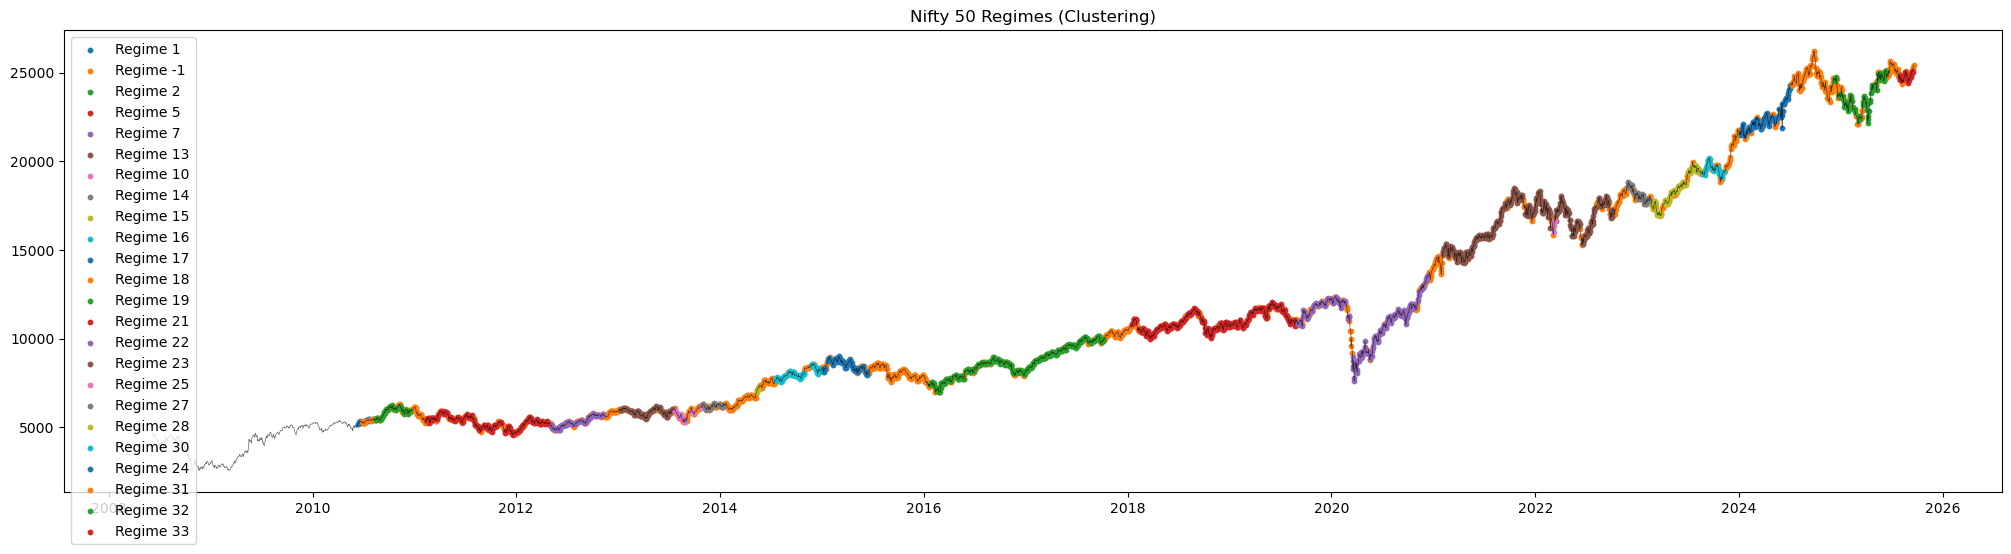

In [13]:
plt.figure(figsize=(25,6))

for c in df['HDBSCAN_Labels'].dropna().unique():
    mask = df['HDBSCAN_Labels'] == c
    plt.scatter(df.index[mask], df['Close'][mask], label=f"Regime {c}", s=10)
plt.plot(df.index, df['Close'], color='black', linewidth=0.5, alpha=0.6)
plt.title("Nifty 50 Regimes (Clustering)")
plt.legend()
plt.show()

In [26]:
import numpy as np


from sklearn.covariance import LedoitWolf

def _make_spd(cov: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Force a symmetric PD matrix by eigenvalue flooring."""
    cov = 0.5 * (cov + cov.T)
    w, v = np.linalg.eigh(cov)
    w = np.clip(w, eps, None)
    return (v * w) @ v.T

def estimate_emissions(X, labels, eps=1e-6, exclude_noise=True):
    """
    X: (T, D)
    labels: (T,) stabilized cluster labels (may include pd.NA / np.nan / -1 noise)
    Returns:
        means: (K, D)
        covs : (K, D, D) SPD
    """
    X = np.asarray(X)
    labels = np.asarray(labels, dtype=object)

    # drop NA labels
    valid = ~pd.isna(labels)
    X = X[valid]
    labels = labels[valid].astype(int)

    # optionally drop noise label -1
    if exclude_noise:
        keep = labels != -1
        X = X[keep]
        labels = labels[keep]

    uniq = np.unique(labels)
    K = len(uniq)
    D = X.shape[1]

    means = np.zeros((K, D))
    covs = np.zeros((K, D, D))

    # fallback covariance if a cluster has too few points
    global_cov = _make_spd(np.cov(X.T) + eps * np.eye(D), eps=eps)

    for i, k in enumerate(uniq):
        Xk = X[labels == k]
        means[i] = Xk.mean(axis=0)

        # need enough samples for a stable full covariance
        if Xk.shape[0] < max(3, D + 1):
            cov = global_cov
        else:
            cov = LedoitWolf().fit(Xk).covariance_

        covs[i] = _make_spd(cov + eps * np.eye(D), eps=eps)

    return means, covs

def sticky_transition_matrix(K, stickiness=50.0):
    """
    Higher stickiness → longer regimes
    """
    transmat = np.ones((K, K))
    np.fill_diagonal(transmat, stickiness)
    transmat /= transmat.sum(axis=1, keepdims=True)
    return transmat


def fit_sticky_hmm(X, init_means, init_covs, stickiness=50.0, min_covar=1e-6):
    K, D = init_means.shape

    model = GaussianHMM(
        n_components=K,
        covariance_type="full",
        n_iter=200,
        init_params="",      # do not overwrite provided params
        params="stmc",       # allow refinement
        min_covar=min_covar,
    )

    model.startprob_ = np.ones(K) / K
    model.transmat_ = sticky_transition_matrix(K, stickiness)
    model.means_ = init_means
    model.covars_ = init_covs

    model.fit(np.asarray(X))
    return model


In [27]:
gdf= df.dropna()
gdf = df.drop(["Close", "HDBSCAN_Labels"], axis=1)
gdf

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-05 00:00:00+05:30,0.000000,0.094707,0.000000,0.086095,0.000000,0.052627,0.000000,0.034146,0.049268,0.079448,...,0.022316,0.000000,0.007209,0.042414,0.000000,0.000000,0.097714,0.014177,0.101710,0.000000
2008-06-06 00:00:00+05:30,0.000000,0.096463,0.000000,0.093592,0.000000,0.055477,0.000000,0.038427,0.048164,0.072977,...,0.026902,0.000000,0.004996,0.039518,0.000000,0.000000,0.092051,0.016242,0.101359,0.000000
2008-06-09 00:00:00+05:30,0.000000,0.097814,0.000000,0.100934,0.000000,0.060673,0.000000,0.042575,0.046727,0.065568,...,0.032963,0.000000,0.002542,0.034720,0.000000,0.000000,0.085397,0.017465,0.100786,0.000000
2008-06-10 00:00:00+05:30,0.000000,0.099855,0.000000,0.104100,0.000000,0.071059,0.000000,0.047309,0.046517,0.058178,...,0.038096,0.000000,0.001713,0.030261,0.000000,0.000000,0.080686,0.019027,0.099659,0.000000
2008-06-11 00:00:00+05:30,0.000000,0.100483,0.000000,0.105155,0.000000,0.084748,0.000000,0.052642,0.045687,0.050810,...,0.045469,0.000058,0.000870,0.026759,0.000000,0.000000,0.075993,0.020184,0.097661,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12 00:00:00+05:30,0.150253,0.171876,0.110617,0.016477,0.000274,0.000000,0.104171,0.077467,0.020435,0.000000,...,0.041521,0.073654,0.000000,0.000000,0.025725,0.050502,0.000000,0.019644,0.066028,0.036041
2025-09-15 00:00:00+05:30,0.140572,0.171512,0.102708,0.012511,0.000518,0.000000,0.113352,0.073049,0.019066,0.000000,...,0.039853,0.072866,0.000000,0.000000,0.025318,0.053611,0.000000,0.021749,0.061992,0.034028
2025-09-16 00:00:00+05:30,0.128521,0.175892,0.093519,0.008835,0.000000,0.000000,0.121123,0.067323,0.016315,0.000000,...,0.037340,0.075898,0.000000,0.000000,0.024032,0.058974,0.000000,0.025540,0.057928,0.034247


In [28]:
# estimate_emissions
init_means, init_covs = estimate_emissions(gdf.to_numpy(), df.loc[gdf.index, "HDBSCAN_Labels"].to_numpy())

In [45]:
label_col = "HDBSCAN_Labels"
valid_idx = df[label_col].notna()
if (df.loc[valid_idx, label_col] == -1).any():
    valid_idx &= (df[label_col] != -1)

gdf = df.loc[valid_idx].drop(["Close", label_col], axis=1)

init_means, init_covs = estimate_emissions(
    gdf.to_numpy(),
    df.loc[gdf.index, label_col].to_numpy(),
    eps=1e-5,
    exclude_noise=True,
)

hmm_model = fit_sticky_hmm(
    X=gdf.to_numpy(),
    init_means=init_means,
    init_covs=init_covs,
    stickiness=200.0,  # tune this
    min_covar=1e-5,
)

smoothed_regimes = hmm_model.predict(gdf.to_numpy())

Model is not converging.  Current: 600028.9079039644 is not greater than 635532.8589967609. Delta is -35503.95109279652


In [46]:
regime_probs = hmm_model.predict_proba(gdf.to_numpy())

In [47]:
regime_probs

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [48]:
smoothed_regimes

array([ 0,  0,  0, ..., 22, 22, 22])

In [49]:
gdf["hmm_Labels"] = smoothed_regimes
# Close
gdf["Close"] = df.loc[gdf.index, "Close"]

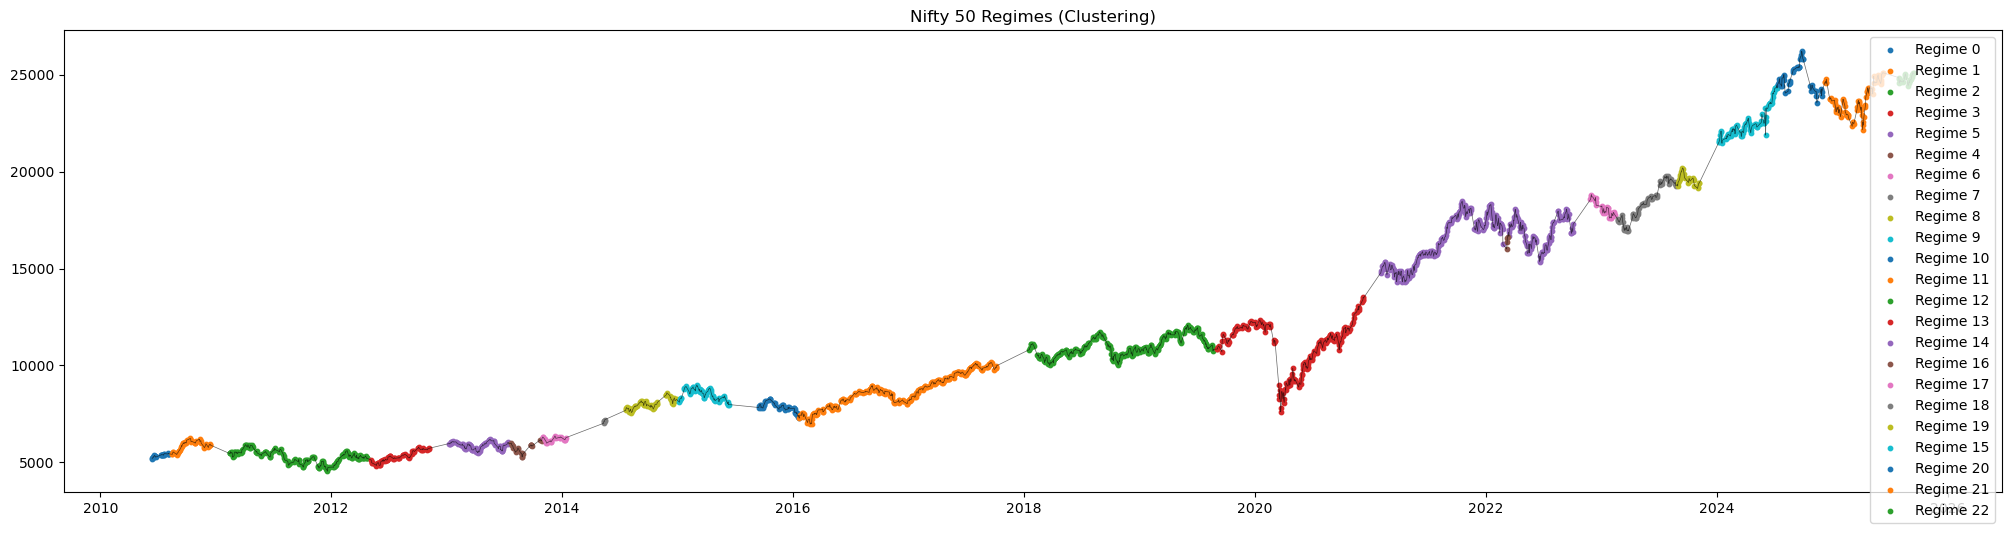

In [50]:
plt.figure(figsize=(25,6))

for c in gdf['hmm_Labels'].dropna().unique():
    mask = gdf['hmm_Labels'] == c
    plt.scatter(gdf.index[mask], gdf['Close'][mask], label=f"Regime {c}", s=10)
plt.plot(gdf.index, gdf['Close'], color='black', linewidth=0.5, alpha=0.6)
plt.title("Nifty 50 Regimes (Clustering)")
plt.legend()
plt.show()